In [ ]:
import numpy as np 
import xarray as xr 
import matplotlib.pyplot as plt 
from matplotlib.cm import ScalarMappable
import torch
from sklearn.model_selection import train_test_split
import torch
import torch.nn.functional as F
from pytorch_tabnet.tab_model import TabNetClassifier
from torch.nn.functional import softmax
from matplotlib.colors import Normalize
from scipy.stats import spearmanr 
from scipy.spatial.distance import cosine

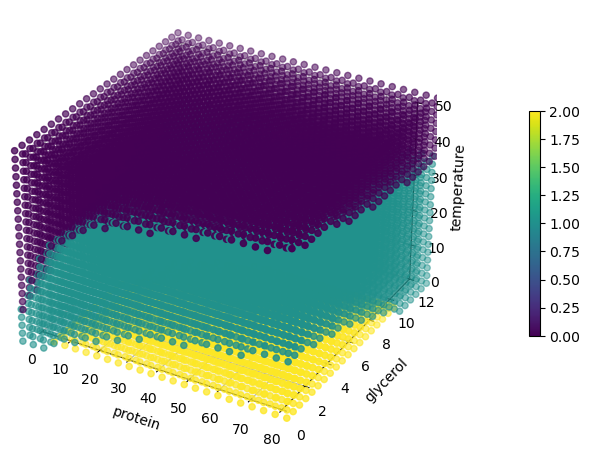

In [2]:
boundary_dataset = xr.load_dataset('250610-extrap_expand_dataset.nc')

fig, ax  = plt.subplots(subplot_kw={"projection":'3d'})

ax = ax
mappable = ax.scatter(
    boundary_dataset["composition"].sel(component='protein').values,
    boundary_dataset["composition"].sel(component='glycerol').values,
    boundary_dataset["composition"].sel(component='temperature').values,
    c=boundary_dataset.labels.values
)
ax.set_xlim(0, 80)
ax.set_ylim(0, 12)
ax.set_zlim(0, 50)
cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
ax.set_xlabel("protein")
ax.set_ylabel("glycerol")
ax.set_zlabel("temperature", labelpad=-1)
plt.tight_layout()
plt.show()

In [3]:
X = boundary_dataset["composition"].values.T
y = boundary_dataset.labels.values 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y) 

In [4]:
# Ensure all inputs are the correct dtype
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
y_train = y_train.astype('int64')
y_test = y_test.astype('int64')

clf = TabNetClassifier()

clf.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)]
)

/Users/knv2/Documents/codebase/envs/3DPhaseDiag/lib/python3.11/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.74203 | val_0_accuracy: 0.40818 |  0:00:00s
epoch 1  | loss: 0.27185 | val_0_accuracy: 0.49699 |  0:00:01s
epoch 2  | loss: 0.20823 | val_0_accuracy: 0.49583 |  0:00:02s
epoch 3  | loss: 0.19096 | val_0_accuracy: 0.52453 |  0:00:02s
epoch 4  | loss: 0.17632 | val_0_accuracy: 0.5796  |  0:00:03s
epoch 5  | loss: 0.17637 | val_0_accuracy: 0.61179 |  0:00:04s
epoch 6  | loss: 0.17372 | val_0_accuracy: 0.61877 |  0:00:04s
epoch 7  | loss: 0.17481 | val_0_accuracy: 0.66395 |  0:00:05s
epoch 8  | loss: 0.16734 | val_0_accuracy: 0.7039  |  0:00:06s
epoch 9  | loss: 0.16733 | val_0_accuracy: 0.72406 |  0:00:06s
epoch 10 | loss: 0.16023 | val_0_accuracy: 0.75082 |  0:00:07s
epoch 11 | loss: 0.1631  | val_0_accuracy: 0.77739 |  0:00:08s
epoch 12 | loss: 0.17242 | val_0_accuracy: 0.77526 |  0:00:08s
epoch 13 | loss: 0.16281 | val_0_accuracy: 0.81385 |  0:00:09s
epoch 14 | loss: 0.16708 | val_0_accuracy: 0.80667 |  0:00:10s
epoch 15 | loss: 0.16087 | val_0_accuracy: 0.82277 |  0

/Users/knv2/Documents/codebase/envs/3DPhaseDiag/lib/python3.11/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


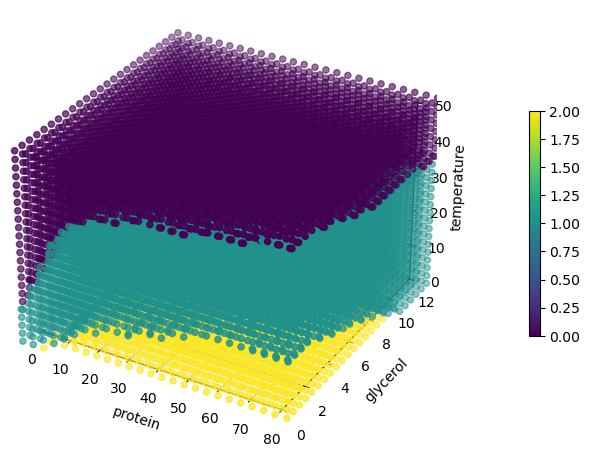

In [5]:
fig, ax  = plt.subplots(subplot_kw={"projection":'3d'})

tabnet_labels = clf.predict(X) 
mappable = ax.scatter(
    boundary_dataset["composition"].sel(component='protein').values,
    boundary_dataset["composition"].sel(component='glycerol').values,
    boundary_dataset["composition"].sel(component='temperature').values,
    c=tabnet_labels
)
ax.set_xlim(0, 80)
ax.set_ylim(0, 12)
ax.set_zlim(0, 50)
cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
ax.set_xlabel("protein")
ax.set_ylabel("glycerol")
ax.set_zlabel("temperature", labelpad=-1)
plt.tight_layout()
plt.show()

In [52]:
ds = xr.load_dataset('./results/product_space_nmax_temp/ds.nc') 

In [53]:
clf.network.eval()
with torch.no_grad():
    Xt = torch.from_numpy(ds.design_space_grid.values).to(torch.float32)
    logits = clf.network(Xt)[0]
probs = softmax(logits, dim=1).numpy()
eps = 1e-12
entropy = -np.sum(probs * np.log(probs + eps), axis=1)

In [54]:
def compute_entropy_gradient(x, clf):
    """
    x: torch.Tensor of shape (d,) or (1, d), requires_grad=True
    clf: classifier object with .network
    """
    clf.network.eval()
    
    if x.ndim == 1:
        x = x.unsqueeze(0)  # shape (1, d)

    x = x.clone().detach().requires_grad_(True)  # Ensure it's a leaf with grad tracking

    logits = clf.network(x.to(torch.float32))[0]  # shape (1, num_classes)
    probs = F.softmax(logits, dim=1)  # shape (1, num_classes)
    
    # Compute entropy 
    entropy = -torch.sum(probs * torch.log(probs + 1e-12), dim=1)  # shape (1,)
    
    # Compute gradient of entropy w.r.t. x
    entropy.backward()

    grad = x.grad.detach().clone()  # shape (1, d)
    return grad.squeeze(0), entropy.detach().item()

entropy, grad = [], []
for xt in Xt:
    g, e = compute_entropy_gradient(xt, clf)
    entropy.append(e)
    grad.append(g)
entropy = np.asarray(entropy)
grad = torch.stack(grad, dim=0)

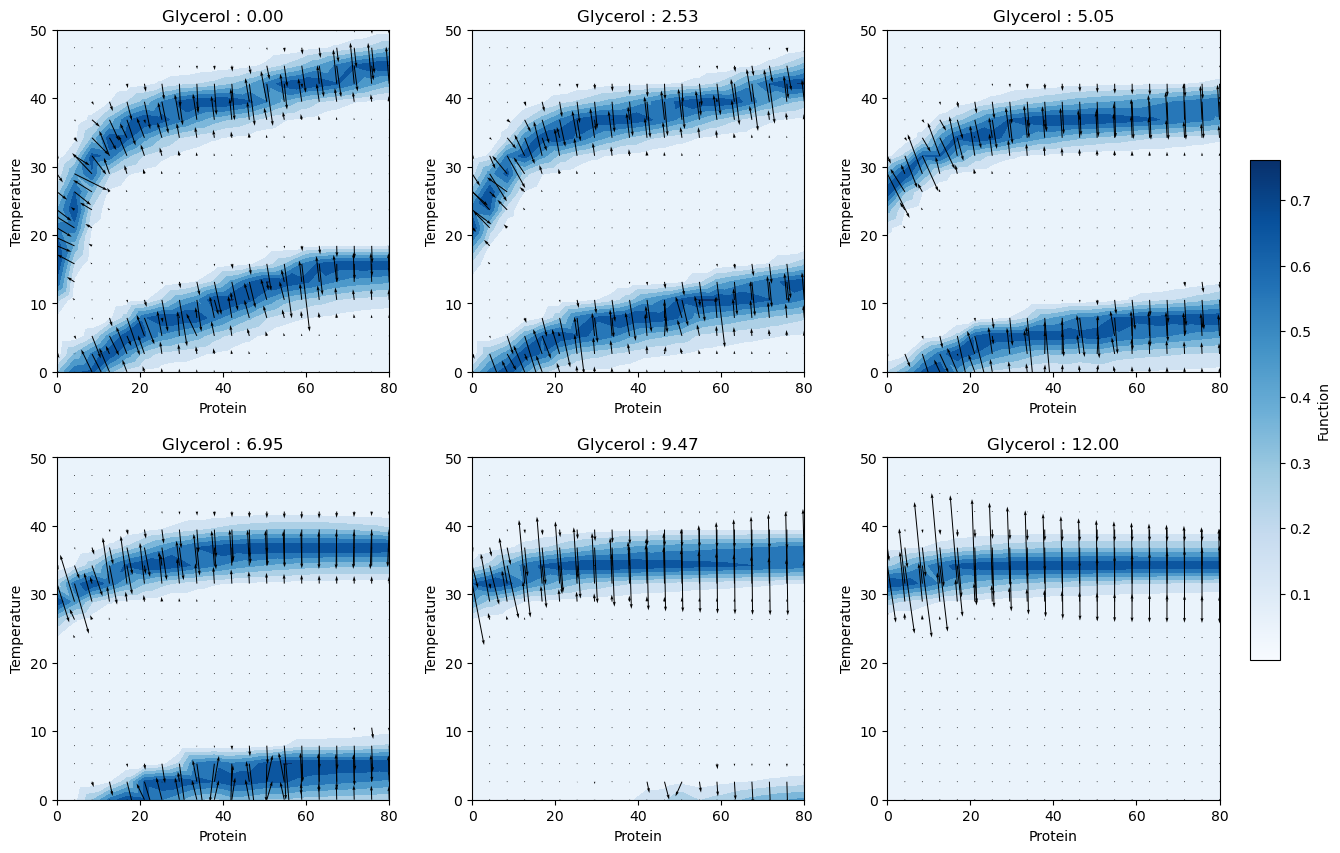

In [55]:
def plot_gradient_field(domain, func, grad):
    norm = np.linalg.norm(grad, axis=1, keepdims=True)
    scale_factor = 0.1
    disp_unit = grad/ (norm + 1e-12)  # add epsilon to avoid division by zero
    disp_scaled = disp_unit * (norm * scale_factor)
    
    fig, axs = plt.subplots(2,3, figsize=(5*3, 5*2))
    fig.subplots_adjust(hspace=0.25, wspace=0.25)
    axs = axs.flatten()
    glycerol_levels = np.unique(domain[:,2])
    indices = torch.linspace(0, len(glycerol_levels)-1, steps=6).round().long()
    cmap = plt.get_cmap("Blues")
    cnorm = Normalize(vmin=func.min(), vmax=func.max())
    sm = ScalarMappable(norm=cnorm, cmap=cmap)

    for i, level in enumerate(glycerol_levels[indices]):
        flags = np.isclose(domain[:,2], level, atol=1/100)
        ax = axs[i]
        cf = ax.tricontourf(domain[flags,0],
                      domain[flags,1],
                      func[flags].squeeze(),
                      cmap = cmap,
                      norm = cnorm
                    )
        ax.quiver(domain[flags,0], 
                  domain[flags,1], 
                  disp_scaled[flags,0], 
                  disp_scaled[flags, 1],
                )
        ax.set_title(f"Glycerol : {level:.2f}")
        ax.set_xlabel("Protein")
        ax.set_ylabel("Temperature")
    ax_cb = fig.add_axes([0.92, 0.25, 0.02, 0.5]) 
    cbar = fig.colorbar(sm, cax=ax_cb, shrink=0.5, pad=0.15)
    cbar.set_label("Function")

    plt.show()

plot_gradient_field(ds.design_space_grid.values, entropy, grad.numpy())


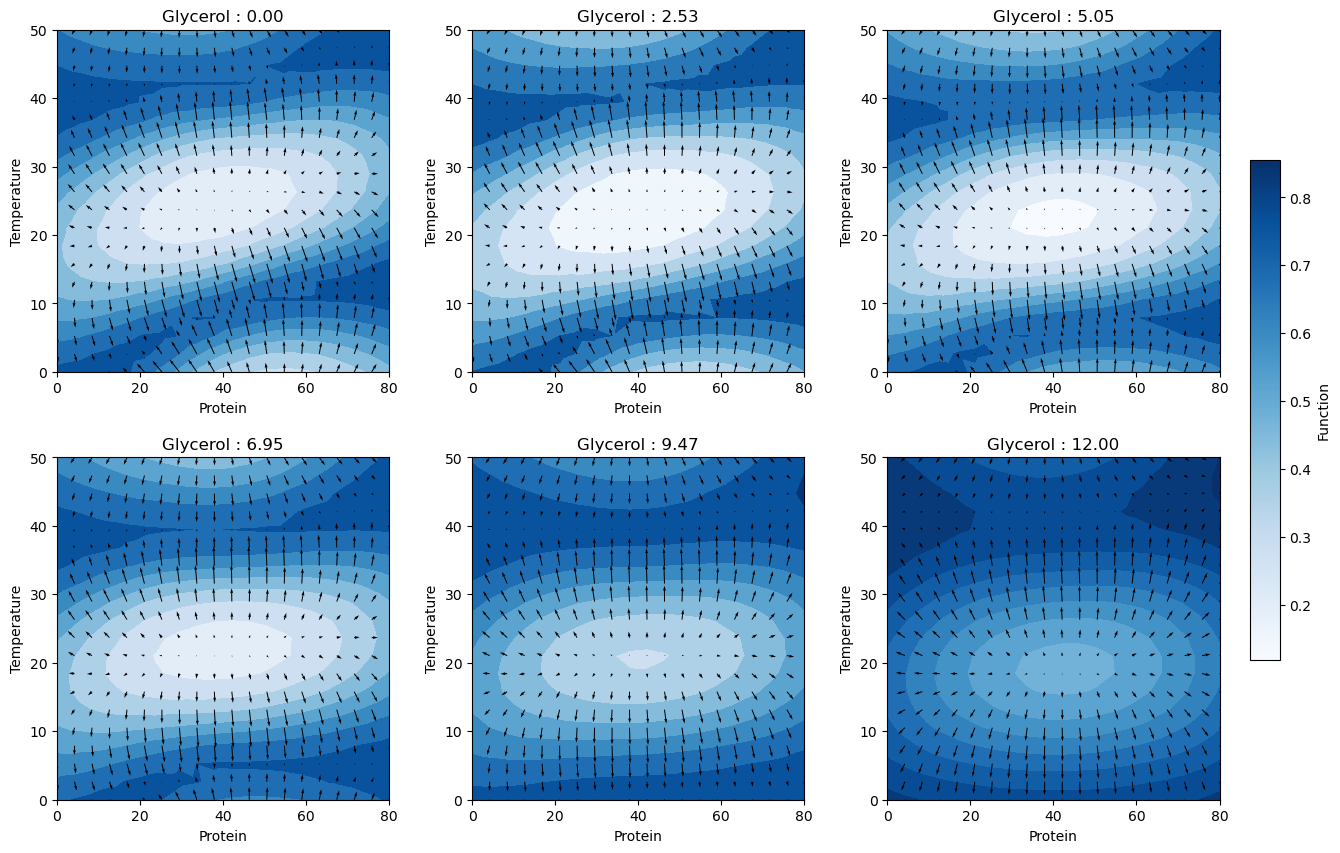

In [56]:
plot_gradient_field(
    ds.design_space_grid.values, 
    ds.phase_entropy.values, 
    ds.phase_entropy_gradient.values
)

In [57]:
dist = 0.0
n = ds.design_space_grid.shape[0]
for i in range(n):
    u = grad.numpy()[i, :]
    v = ds.phase_entropy_gradient.values[i,:]
    dist += 1- cosine(u, v)
print(f"Distance: {dist/n:.2f}")

Distance: 0.27


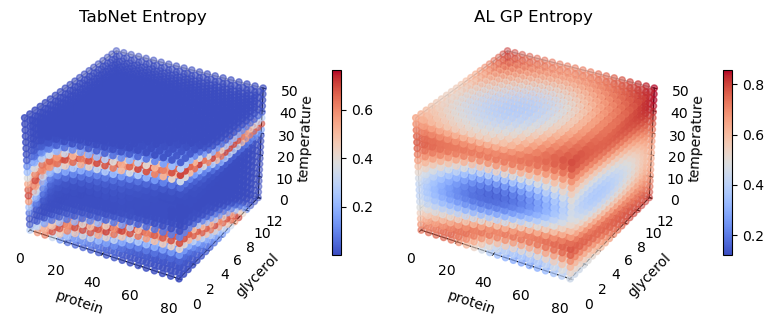

In [58]:
fig, axs  = plt.subplots(1,2, figsize=(4*2, 4), subplot_kw={"projection":'3d'})


axs[0].set_title("TabNet Entropy")
axs[1].set_title("AL GP Entropy")
for ax, f in zip(axs, [entropy, ds.phase_entropy.values]):
    mappable = ax.scatter(
        ds["design_space_grid"].sel(ds_dim='protein').values,
        ds["design_space_grid"].sel(ds_dim='glycerol').values,
        ds["design_space_grid"].sel(ds_dim='temperature').values,
        c=f,
        cmap="coolwarm"
    )
    ax.set_xlim(0, 80)
    ax.set_ylim(0, 12)
    ax.set_zlim(0, 50)
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
    ax.set_xlabel("protein")
    ax.set_ylabel("glycerol")
    ax.set_zlabel("temperature", labelpad=-1)
plt.tight_layout()
plt.show()

In [59]:
corr, _ = spearmanr(entropy, ds.phase_entropy.values)
print("Spearman correlation:", corr)

Spearman correlation: 0.21832764676248828
